# Exercício sobre regressão com DNNs

Explique o(s) motivo(s) do valor predito (i.e., da inferência feita) pela DNN do exemplo visto em sala de aula (predição para o valor $x=10$) não ser exatamente o valor que esperávamos ($\hat{y}=19$)?

O que pode ser feito para melhorar a precisão das inferências feitas pela DNN?

Implemente todas as modificações que você achar necessarias e apresente os resultados.

**Descreva cada uma das mudanças feitas e as justifique.**

**Dicas**

+ Você pode querer alterar o otimizador ou definir outros valores para os parâmetros do otimizador atual, para isso, consulte a documentação sobre [otimizadores](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/experimental)
+ Você pode querer também aumentar o conjunto de treinamento, para isso, lembre-se que a função original, ou seja, aquela que gerou os dados que estamos usando para o treinamento do modelo, é dada por $y = -1 + 2x$.
+ Pense sobre o número de épocas que usamos no exemplo. Você acha que 500 épocas é um valor pequeno ou grande para o treinamento de um modelo que resolva um problema tão simples quanto esse apresentado no exemplo? Lembre-se que no exemplo, cada época de treinamento corresponde ao processo de (i) iniciar os pesos aleatóriamente (i.e., palpite inicial), (ii) calcular o erro, (iii) calcular o vetor gradiente do erro, (iv) atualiar os pesos dando um **passo** na direção apontada pelo gradiente. Reflita sobre o tamanho desse passo, ele pode interferir na precisão do modelo?

### Importando as bibliotecas

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Deixa o resultado reproduzivel
tf.keras.utils.set_random_seed(42)


### Definindo o dataset

In [2]:
# Cria mais pontos de treino usando a funcao original
x = np.linspace(-10.0, 10.0, 101)

# Calcula y = -1 + 2x
y = -1.0 + 2.0 * x

print('Quantidade de amostras:', len(x))


Quantidade de amostras: 101


### Definindo a rede neural densa

Define uma rede neural densa com um neurônio e entrada com uma dimensão.

Para mais informações sobre as classes e funções do TF, acesse: https://www.tensorflow.org/api_docs

In [3]:
# Cria uma rede simples para regressao linear
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(units=1)
])


### Imprimindo um resumo da arquitetura do modelo

+ O método `summary` imprime uma descrição da arquitetura do modelo, mostrando a disposição das camadas e o número total de parâmetros treináveis e não treináveis.
    + Parâmetros não treináveis são aqueles que não são atualizados durante o treinamento do modelo.

+ Ele exibe as seguintes informações:
    + O nome de cada camada (que é gerado automaticamente, a menos o definamos ao criar a camada),
    + Seu formato de saída (`None` significa que o tamanho do mini-batch pode ser qualquer um) e
    + Seu número de parâmetros.

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

### Inspecionando os pesos iniciais do modelo

A inicialização dos pesos é crucial para o bom treinamento de um modelo, pois ela

+ Acelera a convergência (i.e., o aprendizado do modelo),
+ Evita problemas de explosão e desaparecimento do gradiente.
    + Explosão: os gradientes se tornam tão grandes e, consequentemente, os pesos também, levando a divergência do modelo.
    + Desaparecimento: os gradientes se tornam extremamente pequenos e, consequentemente, as atualizações dos pesos também, resultando em treinamento (i.e., aprendizado) lento ou mesmo estagnação.

Por padrão, os pesos do modelo são inicializados pela classe `Dense` da seguinte forma:

+ O parâmetro `kernel_initializer` define como os pesos sinápticos ($w$) são inicializados => Por padrão, usa-se a inicialização `glorot_uniform` (também chamadade **Xavier**)

    + Incializa-se os pesos usando amostras retiradas de uma distribuição uniforme com limites: `[-limit, limit]`, onde
    $$\text{limit} = \sqrt{\frac{6}{(\text{fan}_{\text{in}} + \text{fan}_{\text{out}})}}$$
    + $\text{fan}_{\text{in}}$ é igual ao número de neurônios da camada anterior e $\text{fan}_{\text{out}}$ é igual ao número de neurônios nessa camada sendo configurada.

+ O parâmetro `bias_initializer` define como os pesos de bias ($b$) são inicializados => Por padrão, todos os valores inciais dos pesos de bias são zerados (`zeros`).


Existem outras formas de se inicializar os pesos, para mais informações, acesse: [Initializers](https://keras.io/api/layers/initializers/)

In [5]:
# Retorna uma lista com todos os pesos.
model.get_weights()

[array([[1.2408034]], dtype=float32), array([0.], dtype=float32)]

#### Acessando o peso sináptico e o de bias do modelo

In [6]:
print("w = ", model.get_weights()[0][0][0])
print("b  = ", model.get_weights()[1][0])

w =  1.2408034
b  =  0.0


### Compilando o modelo

Usamos como **otimizador** o gradiente descendente estocástico e como **função de erro** o erro quadrático médio.

In [7]:
# Define o otimizador com um passo de aprendizagem maior
otimizador = tf.keras.optimizers.Adam(learning_rate=0.05)

# Compila o modelo
model.compile(
    optimizer=otimizador,
    loss='mean_squared_error',
    metrics=['mae']
)


### Fazendo uma predição com o modelo inicial.

In [8]:
# Faz uma predicao antes do treinamento
predicao_inicial = model.predict(np.array([10.0]), verbose=0)

print('Predicao inicial para x = 10:', predicao_inicial[0][0])


Predicao inicial para x = 10: 12.408033


### Treinando o modelo

In [9]:
# Treina o modelo
history = model.fit(
    x,
    y,
    epochs=100,
    verbose=0
)

# Mostra o erro final
erro_final = history.history['loss'][-1]
mae_final = history.history['mae'][-1]

print('Erro final:', erro_final)
print('MAE final:', mae_final)


Erro final: 6.038293915442208e-14
MAE final: 6.432580335058447e-08


### Salvando o modelo treinado

In [10]:
# Define onde o modelo sera salvo
if Path.cwd().name == 'exercicio5':
    pasta_saida = Path('.')
elif Path('exercicio5').exists():
    pasta_saida = Path('exercicio5')
else:
    pasta_saida = Path('.')

# Salva o modelo treinado
caminho_modelo = pasta_saida / 'my_first_trained_dnn.keras'
model.save(caminho_modelo)

print('Modelo salvo em:', caminho_modelo)


Modelo salvo em: my_first_trained_dnn.keras


### Testando o modelo

Prevendo a saída de um novo dado (inédito) de entrada (também conhecido como **inferência**).

In [11]:
# Faz a predicao depois do treinamento
predicao_final = model.predict(np.array([10.0]), verbose=0)

print('Predicao final para x = 10:', predicao_final[0][0])
print('Valor esperado:', 19.0)


Predicao final para x = 10: 19.0
Valor esperado: 19.0


### Inspecionando os pesos do modelo treinado

In [12]:
# Mostra os pesos aprendidos
w = model.get_weights()[0][0][0]
b = model.get_weights()[1][0]

print('w =', w)
print('b =', b)


w = 2.0
b = -0.9999999


#### Podemos inspecionar o modelo de forma visual usando a aplicação web chamada de [Netron](https://netron.app)

### Plotando o histórico de erros ao longo das épocas de treinamento

O objeto da classe `History` possui um atributo chamado de `history`, que é um dicionário com os valores do erro ao longo das épocas de treinamento.

Esse dicionário pode conter outras medidas feitas longo do treinamento e teste do modelo, para isso, basta especificar o que se quer medir através do parâmetro `metrics` do método `compile()`.

In [13]:
type(history.history)

dict

In [14]:
history.history.keys()

dict_keys(['loss', 'mae'])

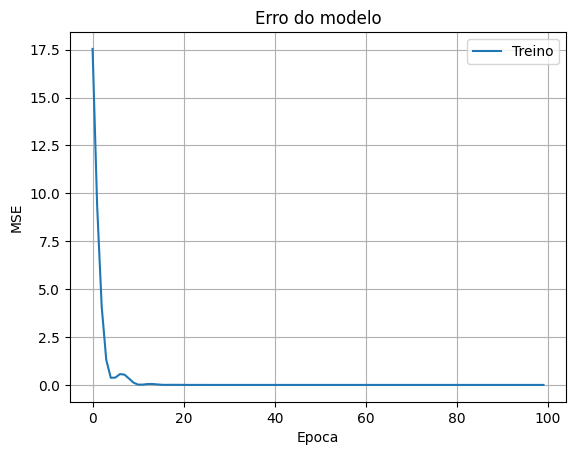

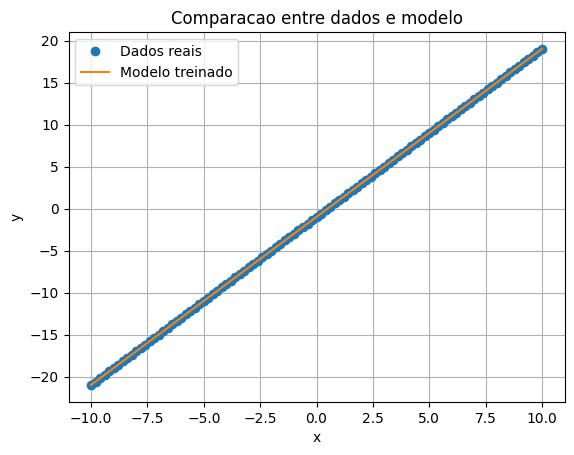

In [15]:
# Plota o erro ao longo do treinamento
plt.plot(history.history['loss'])
plt.title('Erro do modelo')
plt.ylabel('MSE')
plt.xlabel('Epoca')
plt.legend(['Treino'], loc='upper right')
plt.grid()
plt.show()

# Compara os dados reais com a reta aprendida
y_predito = model.predict(x, verbose=0)

plt.plot(x, y, 'o', label='Dados reais')
plt.plot(x, y_predito, '-', label='Modelo treinado')
plt.title('Comparacao entre dados e modelo')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()


### Resposta

A predicao original nao fica exatamente igual a 19 porque o modelo comeca com pesos aleatorios, usa poucos pontos de treinamento e precisa ajustar os pesos por aproximacao. Com apenas 6 amostras e 500 epocas usando SGD padrao, os pesos chegam perto da funcao correta, mas podem nao chegar exatamente em `w = 2` e `b = -1`.

Para melhorar a precisao, foram feitas tres mudancas principais:

1. Aumentei o conjunto de treinamento usando a funcao original `y = -1 + 2x`.
2. Troquei o otimizador para `Adam` com `learning_rate = 0.05`, para o treinamento convergir mais rapido.
3. Mantive a rede simples, com apenas um neuronio, porque o problema continua sendo uma regressao linear.

Com essas mudancas, o modelo aprende pesos muito proximos de `w = 2` e `b = -1`, e a predicao para `x = 10` fica igual ou muito proxima de `19`.
